# Linear Regression
Regression is a statistical method used to model and analyze the relationships between a dependent variable and one or more independent variables. It helps in understanding how the typical value of the dependent variable changes when any one of the independent variables is varied, while the other independent variables are held fixed. Regression is a type of machine learning that predicts continuous numeric outputs. Unlike classiﬁcation, which picks categories, regression gives the actual numbers. Linear regression is the simplest form of regression, where we assume a linear relationship between the input variables (features) and the output variable (target). The goal of linear regression is to find the best-fitting line (or hyperplane in higher dimensions) that minimizes the difference between the predicted values and the actual values.

## Regresstion Concepts
### Best Fit Line
In regression analysis, the best fit line is a straight line that best represents the data points on a scatter plot. It is used to model the relationship between the independent variable (X) and the dependent variable (Y). The best fit line minimizes the distance between itself and all the data points, typically using the least squares method. This line can be used to make predictions about the dependent variable based on new values of the independent variable. The equation of the best fit line is usually expressed as:

Y = mX + b; 
where Y is the dependent variable, X is the independent variable, m is the slope of the line, and b is the y-intercept.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Generate synthetic data
np.random.seed(0)        # use seed to reproduce results, that means same random numbers in every run
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# Create and fit the model  
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [3]:
print("Coefficient (slope):", model.coef_[0])
print("Intercept:", model.intercept_)

# This gives us the slope (m) and intercept (b) of the best-fit line

Coefficient (slope): [2.96846751]
Intercept: [4.22215108]


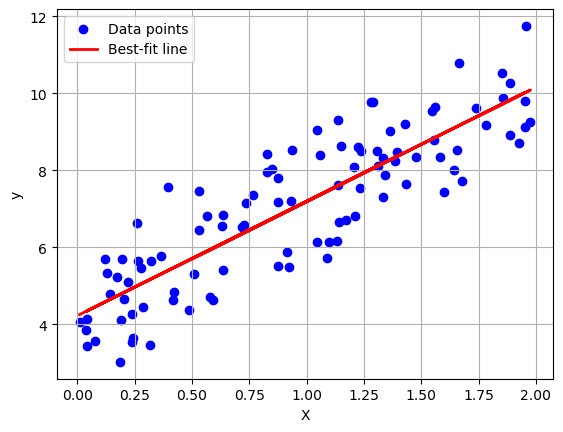

In [4]:
# Visualize and plot the best-fit line

plt.scatter(X, y, color='blue', label='Data points')        # scatter plot of the data points
plt.plot(X, model.predict(X), color='red', linewidth=2, label='Best-fit line')          # plot the regression line(best-fit line)
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Predicting new values
X_new = np.array([[0], [2]])
y_predict = model.predict(X_new)        # It basically puts the new X values in the line equation to get corresponding y values
print("Predictions for new values:", y_predict)

Predictions for new values: [[ 4.22215108]
 [10.1590861 ]]


### Gradient Descent
Gradient descent is an optimization algorithm used to minimize a cost function in machine learning and regression models. It works by iteratively adjusting model parameters such as weights(slope) and biases(intercept) in the direction where the cost decreases fastest. At each step, it updates the slope and intercept, computes the new cost, and keeps moving until the error can’t be reduced further. The cost curve for problems like linear regression is typically shaped like a parabola, so the process slides toward the lowest point. A local minimum is a low point surrounded by higher values but not the lowest overall, while the global minimum is the single lowest point on the entire cost surface.

slope = slope - learning_rate * d(cost)/dslope
intercept = intercept - learning_rate * d(cost)/dintercept

The goal of gradient descent is to find the optimal values of the model parameters that minimize the cost function, leading to better predictions and improved model performance.

#### The Learning Rate
The learning rate is a small number that controls how big each step is when a model updates its parameters during training. If the learning rate is too high, the model might overshoot the lowest point of the cost function and never settle. If it’s too low, the model will move very slowly and take a long time to converge. Choosing the right learning rate is about balance: it should be large enough to reach the minimum efficiently but small enough to avoid bouncing around or missing it entirely.

##### The Gradient Descent Algorithm
1. Initialize the model parameters(slope and intercept) randomly or with zeros.
2. Compute the predicted values using the current parameters.
3. Calculate the cost function (e.g., Mean Squared Error) to evaluate the model's performance.
4. Compute the gradients of the cost function with respect to each parameter.
5. Update the parameters by subtracting the product of the learning rate and the gradients from the current parameters.
6. Repeat steps 2-5 for a specified number of iterations or until the cost function converges to a minimum value.

In [ ]:
from sklearn.linear_model import SGDRegressor 

sgd_model = SGDRegressor(max_iter=1000, learning_rate='invscaling', eta0=0.1,random_state=42)       # max_iter tells how many iterations we want to do, eta0 is the initial learning rate, learning_rate is the schedule for updating the learning rate; 'invscaling' means the learning rate decreases over time
sgd_model.fit(X, y.ravel())        # ravel() is used to convert y from 2D array to 1D array as SGDRegressor expects 1D array for target variable
print("SGD Coefficient (slope):", sgd_model.coef_[0])
print("SGD Intercept:", sgd_model.intercept_[0])

# Predicting new values using SGD model
y_sgd_predict = sgd_model.predict(X_new)
print("SGD Predictions for new values:", y_sgd_predict)

SGD Coefficient (slope): 2.931270387853015
SGD Intercept: 4.159468489083948
SGD Predictions for new values: [ 4.15946849 10.02200926]


### Best Fit Line vs Gradient Descent
The best fit line is a specific solution in regression analysis that represents the optimal linear relationship between the independent and dependent variables, typically found using methods like least squares. In contrast, Gradient Descent is an iterative optimization algorithm used to minimize the cost function by adjusting model parameters, which can be applied to find the best fit line or other types of models. In non-linear regression or complex models, Gradient Descent is often employed to approximate the best fit line when analytical solutions are not feasible.

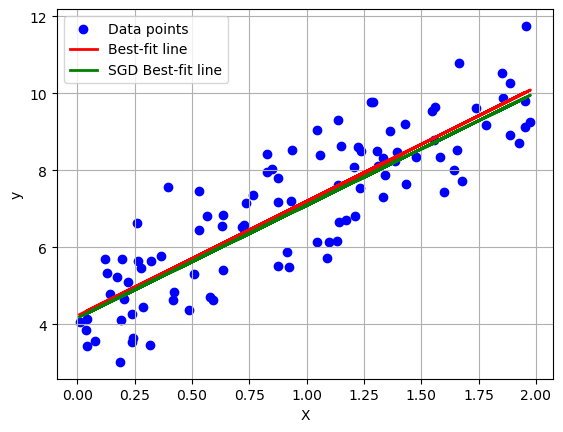

In [12]:
plt.scatter(X, y, color='blue', label='Data points')        # scatter plot of the data points
plt.plot(X, model.predict(X), color='red', linewidth=2, label='Best-fit line')          # plot the regression line(best-fit line) from Linear Regression
plt.plot(X, sgd_model.predict(X), color='green', linewidth=2, label='SGD Best-fit line')          # plot the regression line(best-fit line) from SGD
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

## Cost Function
In regression analysis, the cost function is a mathematical function that quantifies the error or difference between the predicted values generated by a regression model and the actual observed values from the dataset. The most commonly used cost function in regression is the Mean Squared Error (MSE), which calculates the average of the squared differences between predicted and actual values. The goal of regression is to minimize this cost function, thereby improving the accuracy of the model's predictions. By adjusting the model parameters (such as the slope and intercept in linear regression), we can find the optimal values that result in the lowest possible cost, leading to better predictive performance.

### Mean Squared Error (MSE)
Mean Squared Error (MSE) is a common metric used to evaluate the performance of regression models. It measures the average of the squares of the errors—that is, the average squared difference between the predicted values and the actual values. The formula for MSE is: 

MSE = (1/n) * Σ(actual - predicted)²

where n is the number of data points, actual represents the true values, and predicted represents the values predicted by the model. A lower MSE indicates a better fit of the model to the data, as it signifies that the predicted values are closer to the actual values.

In [14]:
from sklearn.metrics import mean_squared_error

# Calculating Mean Squared Error for Linear Regression model
mse_linear_model = mean_squared_error(y, model.predict(X))          # It calculates the mean squared error between actual y values and predicted y values by the linear model for given X values
print("Mean Squared Error (Linear Regression Model):", format(mse_linear_model, ".4f"))


# Calculating Mean Squared Error for SGD model
mse_sgd_model = mean_squared_error(y, sgd_model.predict(X))
print("Mean Squared Error (SGD Regression Model):", format(mse_sgd_model, ".4f"))

Mean Squared Error (Linear Regression Model): 0.9924
Mean Squared Error (SGD Regression Model): 1.0025


### Regressuion Evaluation Metrics
1. Mean Absolute Error (MAE)

Mean Absolute Error (MAE) is a metric used to evaluate the performance of regression models by measuring the average absolute difference between the predicted values and the actual values. It is calculated using the formula:

```math
MAE = (1/n) * Σ|actual - predicted|
```
where n is the number of data points, actual represents the true values, and predicted represents the values predicted by the model. MAE provides a straightforward interpretation of the average error in the same units as the target variable, making it easy to understand. A lower MAE indicates better model performance, as it signifies that the predictions are closer to the actual values.

2. Root Mean Squared Error (RMSE)

Root Mean Squared Error (RMSE) is a widely used metric for evaluating the performance of regression models. It measures the square root of the average of the squared differences between the predicted values and the actual values. The formula for RMSE is:

```math
RMSE = \sqrt{\frac{1}{n} \sum (actual - predicted)^2}
```
where n is the number of data points, actual represents the true values, and predicted represents the values predicted by the model. RMSE provides a measure of how well the model's predictions align with the actual data, with a lower RMSE indicating better model performance. It is particularly useful because it penalizes larger errors more than smaller ones, making it sensitive to outliers in the data.

3. R-squared (R²)

R-squared (R²) is a statistical metric used to evaluate the performance of regression models by measuring the proportion of variance in the dependent variable that can be explained by the independent variable(s). It means how closely the data points fit the regression line. The value of R² ranges from 0 to 1, where 0 indicates that the model does not explain any of the variance in the dependent variable, and 1 indicates that the model perfectly explains all the variance. A higher R² value signifies a better fit of the model to the data, indicating that a larger proportion of the variability in the outcome can be accounted for by the predictors used in the model. The formula for R-squared is:

```math
R^2 = 1 - \frac{SS_{res}}{SS_{tot}}
```
where SS_res is the sum of squares of residuals (the differences between actual and predicted values), and SS_tot is the total sum of squares (the differences between actual values and the mean of actual values).

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculating regression metrics for Linear Regression model
mae = mean_absolute_error(y, model.predict(X))          # Mean Absolute Error
mse = mean_squared_error(y, model.predict(X))           # Mean Squared Error
rmse = np.sqrt(mse)  # Root Mean Squared Error
r2 = r2_score(y, model.predict(X))                       # R-squared (Coefficient of Determination)

print("\nRegression Metrics for Linear Regression Model:")
print("Mean Absolute Error (MAE):", format(mae, ".4f"))
print("Mean Squared Error (MSE):", format(mse, ".4f"))
print("Root Mean Squared Error (RMSE):", format(rmse, ".4f"))
print("R-squared (R²):", format(r2, ".4f"))

# Calculating regression metrics for SGD model
mae_sgd = mean_absolute_error(y, sgd_model.predict(X))          # Mean Absolute Error
mse_sgd = mean_squared_error(y, sgd_model.predict(X))           # Mean Squared Error
rmse_sgd = np.sqrt(mse_sgd)  # Root Mean Squared Error
r2_sgd = r2_score(y, sgd_model.predict(X))                       # R-squared (Coefficient of Determination)

print("\nRegression Metrics for SGD Regression Model:")
print("Mean Absolute Error (MAE):", format(mae_sgd, ".4f"))
print("Mean Squared Error (MSE):", format(mse_sgd, ".4f"))
print("Root Mean Squared Error (RMSE):", format(rmse_sgd, ".4f"))
print("R-squared (R²):", format(r2_sgd, ".4f"))


Regression Metrics for Linear Regression Model:
Mean Absolute Error (MAE): 0.8493
Mean Squared Error (MSE): 0.9924
Root Mean Squared Error (RMSE): 0.9962
R-squared (R²): 0.7470

Regression Metrics for SGD Regression Model:
Mean Absolute Error (MAE): 0.8546
Mean Squared Error (MSE): 1.0025
Root Mean Squared Error (RMSE): 1.0012
R-squared (R²): 0.7444


#### Which Regression Metric to Use?
| Metric               | Description                                                                                     | Use Case                                                                                   |
|----------------------|-------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------|
| Mean Absolute Error (MAE) | Measures the average absolute difference between predicted and actual values.                  | When a straightforward interpretation of average error in the same units as the target variable is desired. |
| Root Mean Squared Error (RMSE) | Measures the square root of the average squared differences between predicted and actual values. | When the goal is to penalize larger errors more heavily, as RMSE is sensitive to outliers. |
| R-squared (R²)      | Measures the proportion of variance in the dependent variable explained by the independent variable(s). | When the goal is to assess how well the model explains the variability in the data.       |

### Assumptions of Linear Regression
#### Why are Assumptions Important?
Linear regression is powerful, but it only works reliably when certain conditions are met. When these assumptions are violated, the risk:
- Unreliable predictions that don't match reality
- Misleading coefﬁcients that distort relationships
- Increased errors that reduce model accuracy

#### Key Assumptions
1. Linearity: The relationship between the independent and dependent variables should be linear.
2. Independence: The residuals (errors) should be independent of each other. Means that the value of one error should not inﬂuence another.
3. Homoscedasticity(Unequal spread): The residuals should have constant variance at all levels of the independent variable(s). This means that the spread of the residuals should be consistent across all values of the independent variable(s). If the variance of the residuals changes at different levels of the independent variable(s), it indicates heteroscedasticity, which can lead to inefficiencies in the estimates and affect the validity of hypothesis tests.
4. Normality of Residuals: The residuals should be approximately normally distributed. This assumption is important for conducting hypothesis tests and constructing confidence intervals for the regression coefficients. A single extreme value can dramatically shift the regression line and distort all predictions.
5. No Multicollinearity: In multiple regression, the independent variables should not be highly correlated with each other. High multicollinearity can make it difficult to determine the individual effect of each independent variable on the dependent variable.  

### Limitaion of Linear Regression
1. Can not capture non-linear relationships(exponential,polynomial, logarithmic, etc.).
2. Highly sensitive to outliers.
3. Can not classify categories.
4. Misses complex interactions between features. 

### When not to use Linear Regression
1. Non-linear relationships.
2. Strong seasonal patterns(repeated cycles over time).
3. Extreme outliers present.
4. High multicollinearity among independent variables.
5. Classification tasks (categorical outcomes).

### Linear Regression Boundaries
- Output can be any real number (positive or negative).
- No natural bounds on predictions.
- Hard to interpret probabilities directly.

# Logistic Regression
Logistic Regression is a statistical method used for binary classification tasks, where the goal is to predict one of two possible outcomes based on one or more independent variables. Unlike linear regression, which predicts continuous numeric values, logistic regression predicts the probability of an event occurring, typically represented as a value between 0 and 1. The model uses the logistic function (also known as the sigmoid function) to transform the linear combination of input features into a probability score. If the predicted probability is above a certain threshold (commonly 0.5), the outcome is classified as one class (e.g., "1" or "positive"), and if it is below the threshold, it is classified as the other class (e.g., "0" or "negative"). Logistic regression is widely used in various fields, including medicine, finance, and social sciences, for tasks such as disease diagnosis, credit scoring, and customer churn prediction. 

### Logistic Regression Steps
1. Step 1: Linear Score Calculation
   - Compute the linear combination of input features using weights and bias.
   - Formula: z = w1*x1 + w2*x2 + ... + wn*xn + b
2. Step 2: Apply Sigmoid Function
   - Transform the linear score into a probability using the sigmoid function.
   - Formula: p = 1 / (1 + e^(-z))
3. Step 3: Classification Decision or Interpretation
   - Classify the outcome based on a threshold (commonly 0.5) or interpret the probability.
   - If p >= 0.5, classify as class "1"; otherwise, classify as class "0". 

## Sigmoid Function
The sigmoid function creates an "S"-shaped curve that maps any real-valued number into a value between 0 and 1. This property makes it particularly useful in logistic regression for converting linear scores into probabilities. The sigmoid function is defined by the formula:

```math
S(z) = 1 / (1 + e^(-z))\\
z=w1*x1 + w2*x2 + ... + wn*xn + b
```

where:
- S(z) is the output of the sigmoid function, representing the probability.
- z is the input to the function, which is typically the linear combination of features in logistic regression.
- w1, w2, ..., wn are the weights(slope) associated with each feature.
- b is the bias term(intercept).

#### When Logistic Regression Failed?
Logistic regression creates linear decision boundaries. This works great when classes can be separated by a straight line, but fails when the relationship is non-linear.

In [5]:
from sklearn.linear_model import LogisticRegression

hours = np.arange(1,11)     # hours studied from 1 to 10
marks = np.array([10, 20, 35, 50, 65, 70, 85, 90, 95, 100])   # corresponding marks
pass_or_fail = np.where(marks >= 50, 1 , 0)   # 1 for pass when marks >= 50, 0 for fail

df = pd.DataFrame({
    'Hours_Studied': hours,
    'Marks': marks,
    'Pass_or_Fail': pass_or_fail
})

X=df[['Hours_Studied']]
y=df['Pass_or_Fail']

logistic_model = LogisticRegression()
logistic_model.fit(X, y)

LogisticRegression()

In [16]:
# Predicting probabilities for new data
new_hours = pd.DataFrame({'Hours_Studied':[2,5,8]})
probabilities = logistic_model.predict_proba(new_hours)
print("Predicted probabilities for new hours studied:")
print(probabilities)

predicted_classes = logistic_model.predict(new_hours)
print("Predicted classes for new hours studied:")
print(predicted_classes)

Predicted probabilities for new hours studied:
[[0.84707214 0.15292786]
 [0.14548712 0.85451288]
 [0.00520608 0.99479392]]
Predicted classes for new hours studied:
[0 1 1]


The sigmoid function returns two probabilities for each input: the probability of belonging to class 0 and the probability of belonging to class 1. The sum of these probabilities is always 1. To predict the class label, it is common to use a threshold of 0.5. If the probability of class 1 is greater than or equal to 0.5, the input is classified as class 1; otherwise, it is classified as class 0.\
[[0.84707214 0.15292786]\
 [0.14548712 0.85451288]\
 [0.00520608 0.99479392]]

For the example above, the predicted probabilities for the three inputs are shown. The first column represents the probability of class 0, and the second column represents the probability of class 1. Based on a threshold of 0.5, the predicted classes for the inputs would be [0, 1, 1], meaning the first input is classified as class 0, while the second and third inputs are classified as class 1.\
For the first row, it gives the probabilities [0.84707214 0.15292786], indicating an 84.71% chance of belonging to class 0 and a 15.29% chance of belonging to class 1. Since the probability of class 1 (15.29%) is less than the threshold of 50%, the predicted class for this input is 0.

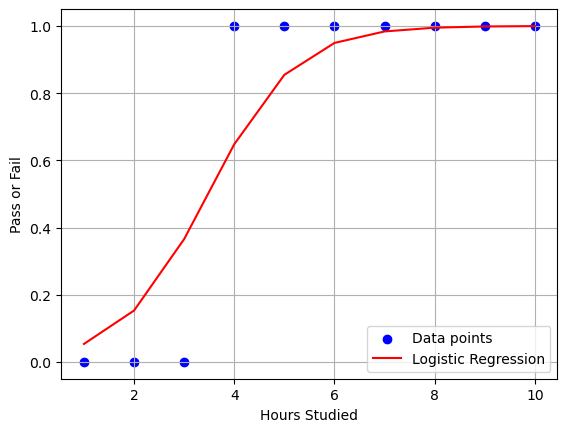

In [18]:
# Visualizing the logistic regression results
plt.scatter(X, y, color='blue', label='Data points')        # scatter plot of the data points
plt.plot(X, logistic_model.predict_proba(X)[:, 1], color='red', label='Logistic Regression')          # plot the regression line(best-fit line) which devides pass and fail
plt.xlabel('Hours Studied')
plt.ylabel('Pass or Fail')
plt.legend()
plt.grid(True)
plt.show()

## Linear vs Logistic Regression
| Aspect               | Linear Regression                                      | Logistic Regression                                   |
|----------------------|--------------------------------------------------------|-------------------------------------------------------|
| Purpose              | Predict continuous numeric values.                     | Predict binary outcomes (0 or 1).                      |
| Output               | Continuous values (any real number).                   | Probabilities (between 0 and 1).                     |
| Interpretation       | Directly predicts the value of the dependent variable. | Predicts the probability of belonging to a class.      |
| Model Type           | Regression model                                      | Classification model                                 |
| Decision Boundary    | Linear (straight line)                                 | Non-linear (S-shaped curve)                           |
| Loss Function        | Mean Squared Error (MSE)                               | Log Loss (Cross-Entropy Loss)                         |
|Best Used For        | Predicting quantities like price, temperature, etc.    | Predicting categories like spam vs. not spam, disease vs. no disease. |